In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from dotenv import load_dotenv

load_dotenv('../.env')

# Find all 12 station files
files = glob.glob('../data/raw/beijing_air/PRSA_Data_*.csv')

print(f"Found {len(files)} station files:")
for f in sorted(files):
    print(" ", os.path.basename(f))

Found 12 station files:
  PRSA_Data_Aotizhongxin_20130301-20170228.csv
  PRSA_Data_Changping_20130301-20170228.csv
  PRSA_Data_Dingling_20130301-20170228.csv
  PRSA_Data_Dongsi_20130301-20170228.csv
  PRSA_Data_Guanyuan_20130301-20170228.csv
  PRSA_Data_Gucheng_20130301-20170228.csv
  PRSA_Data_Huairou_20130301-20170228.csv
  PRSA_Data_Nongzhanguan_20130301-20170228.csv
  PRSA_Data_Shunyi_20130301-20170228.csv
  PRSA_Data_Tiantan_20130301-20170228.csv
  PRSA_Data_Wanliu_20130301-20170228.csv
  PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [3]:
# Combine all 12 into one DataFrame
df = pd.concat(
    [pd.read_csv(f) for f in sorted(files)],
    ignore_index=True
)

print(f"\nCombined shape: {df.shape}")
print(f"Total rows: {len(df):,}")
print(f"\nColumns:")
print(df.columns.tolist())


Combined shape: (420768, 18)
Total rows: 420,768

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


In [4]:
# Save combined file to data/raw/ for pipeline use
df.to_csv('../data/raw/beijing_air.csv', index=False)
print("Saved combined file to data/raw/beijing_air.csv")

Saved combined file to data/raw/beijing_air.csv


In [5]:
# Cell 3 — data types and nulls
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 62.1 MB


In [6]:
# Cell 4 — null rates
null_rates = df.isnull().sum() / len(df) * 100
print("Null rate per column (%):\n")
print(null_rates.sort_values(ascending=False).round(4))

Null rate per column (%):

CO         4.9198
O3         3.1554
NO2        2.8795
SO2        2.1439
PM2.5      2.0769
PM10       1.5327
wd         0.4330
DEWP       0.0958
TEMP       0.0946
PRES       0.0934
RAIN       0.0927
WSPM       0.0756
year       0.0000
No         0.0000
day        0.0000
month      0.0000
hour       0.0000
station    0.0000
dtype: float64


In [7]:
# Cell 5 — statistics
df.describe().round(2)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.00,420768.00,420768.00,420768.00,420768.00,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420365.00,420378.00,420450.00
mean,17532.50,2014.66,6.52,15.73,11.50,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,2.49,0.06,1.73
std,10122.12,1.18,3.45,8.80,6.92,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,13.79,0.82,1.25
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,-8.90,0.00,0.90
50%,17532.50,2015.00,7.00,16.00,11.50,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,3.10,0.00,1.40
75%,26298.25,2016.00,10.00,23.00,17.25,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,15.10,0.00,2.20
max,35064.00,2017.00,12.00,31.00,23.00,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20


In [8]:
# Cell 6 — categorical columns
cat_cols = ['station', 'wd', 'cbwd'] 
existing = [c for c in cat_cols if c in df.columns]

for col in existing:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts())


Column: station
Unique values: 12
station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64

Column: wd
Unique values: 16
wd
NE     43335
ENE    34142
NW     32600
N      30869
E      29752
SW     28756
NNE    28232
NNW    25326
WNW    24375
ESE    24220
SSW    22563
SE     20074
WSW    20040
S      19405
SSE    17694
W      17563
Name: count, dtype: int64


In [9]:
# Cell 7 — check for sensor failure values
print("SENSOR FAILURE CHECK\n" + "="*40)

# -200 or -999 means sensor failed in this dataset
for col in ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']:
    if col in df.columns:
        neg = (df[col] < 0).sum()
        zeros = (df[col] == 0).sum()
        missing = df[col].isnull().sum()
        print(f"{col}: negative={neg:,} | zeros={zeros:,} | nulls={missing:,}")

SENSOR FAILURE CHECK
PM2.5: negative=0 | zeros=0 | nulls=8,739
PM10: negative=0 | zeros=0 | nulls=6,449
SO2: negative=0 | zeros=0 | nulls=9,021
NO2: negative=0 | zeros=0 | nulls=12,116
CO: negative=0 | zeros=0 | nulls=20,701
O3: negative=0 | zeros=0 | nulls=13,277


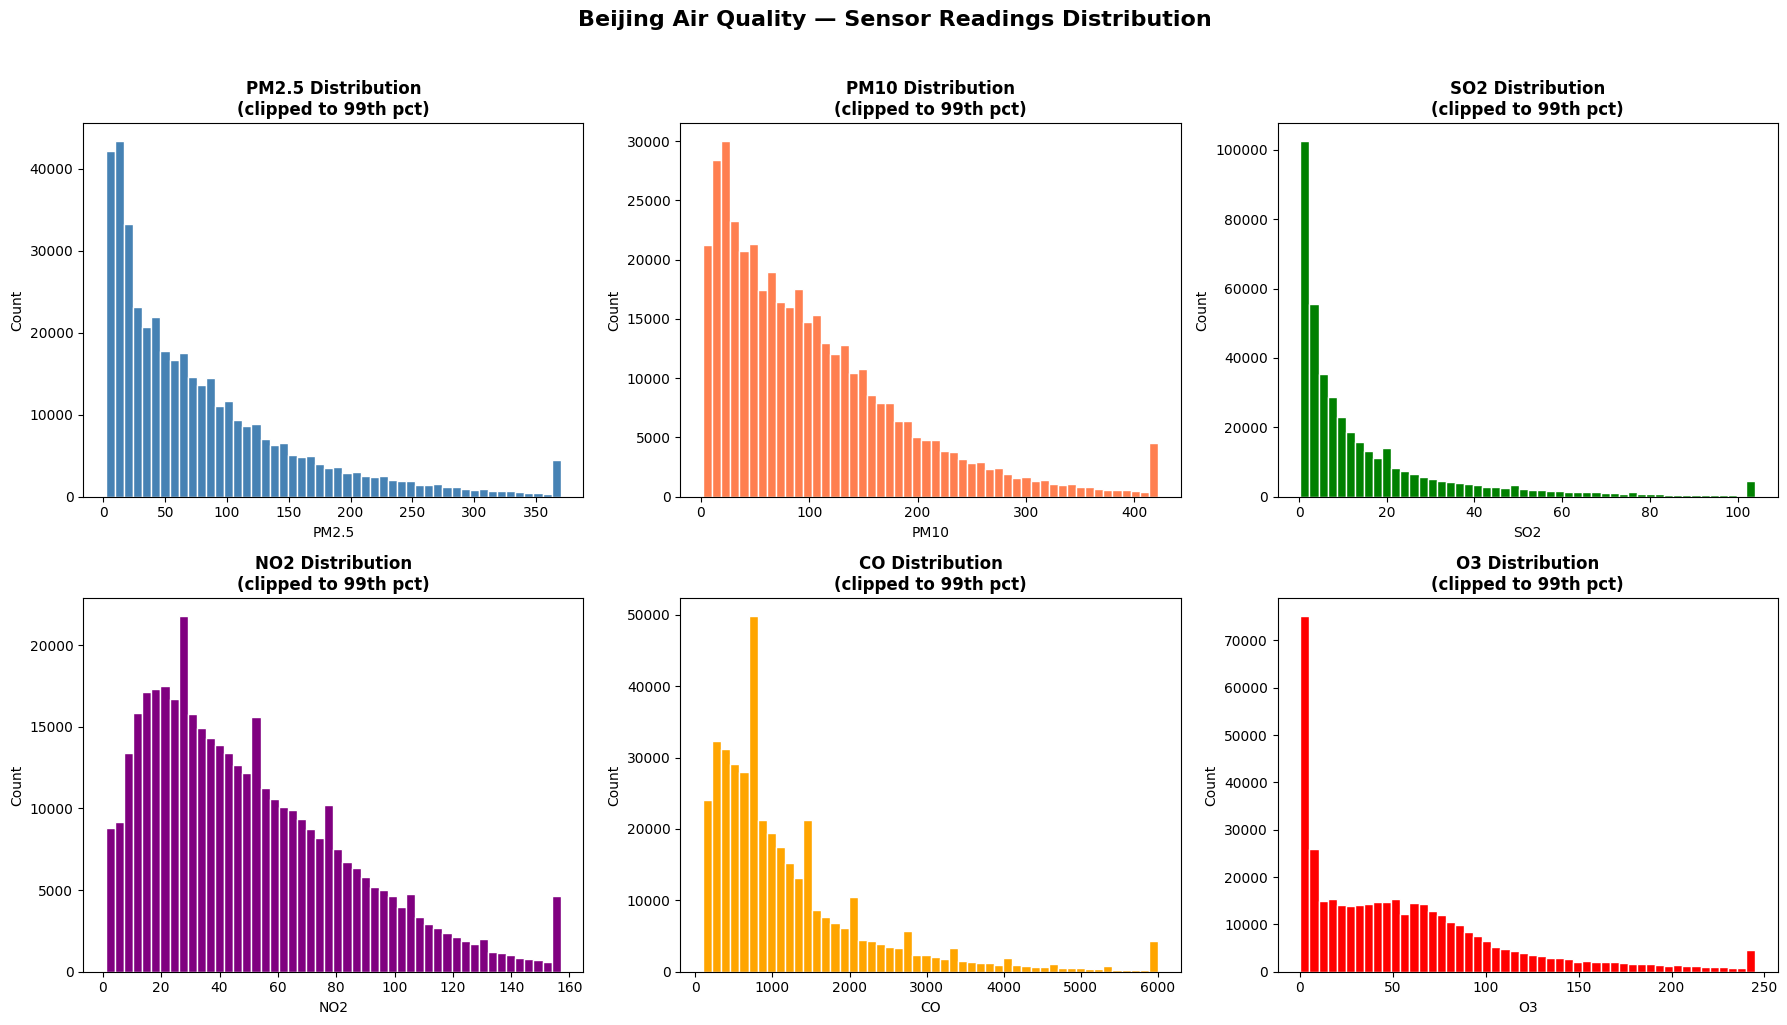

In [10]:
# Cell 8 — distributions
cols_to_plot = [c for c in ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3'] 
                if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'green', 'purple', 'orange', 'red']

for i, (col, color) in enumerate(zip(cols_to_plot, colors)):
    q99 = df[col].quantile(0.99)
    axes[i].hist(
        df[col].clip(0, q99),
        bins=50,
        color=color,
        edgecolor='white'
    )
    axes[i].set_title(f'{col} Distribution\n(clipped to 99th pct)', 
                      fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Beijing Air Quality — Sensor Readings Distribution',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

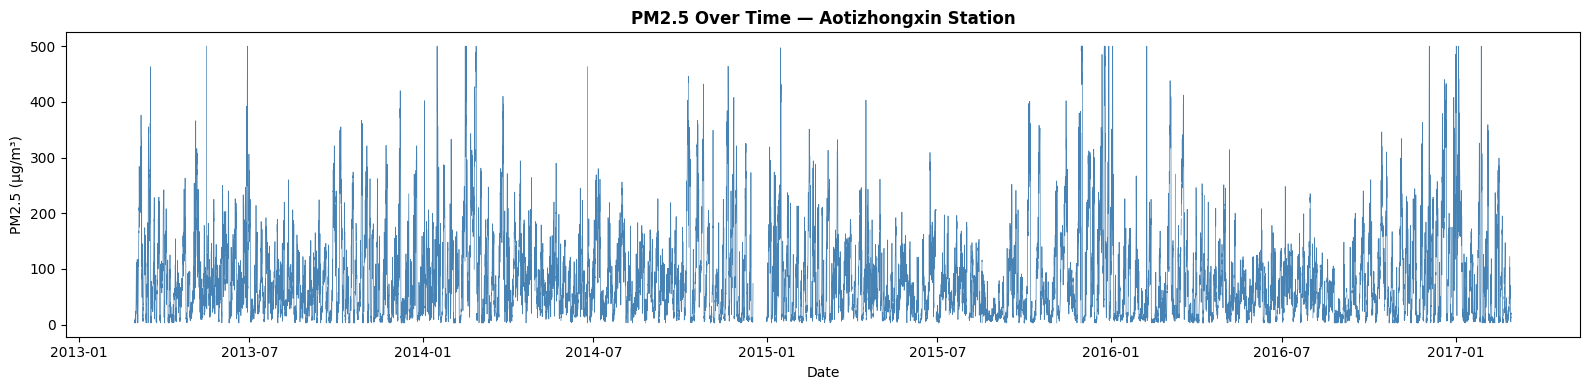

In [11]:
# Cell 9 — time series plot for one station
station_name = df['station'].unique()[0]
one_station = df[df['station'] == station_name].copy()

# Create datetime column
one_station['datetime'] = pd.to_datetime(
    one_station[['year', 'month', 'day', 'hour']]
)
one_station = one_station.sort_values('datetime')

plt.figure(figsize=(16, 4))
plt.plot(
    one_station['datetime'],
    one_station['PM2.5'].clip(0, 500),
    linewidth=0.5,
    color='steelblue'
)
plt.title(f'PM2.5 Over Time — {station_name} Station', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

In [12]:
# Cell 10 — percentile table
air_cols = [c for c in ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES'] 
            if c in df.columns]

percentiles = [0.01, 0.25, 0.50, 0.75, 0.95, 0.99]
result = df[air_cols].quantile(percentiles)
result.index = [f'{int(p*100)}th' for p in percentiles]
print("Percentile table:\n")
print(result.round(2).to_string())

Percentile table:

      PM2.5   PM10    SO2    NO2      CO     O3  TEMP    PRES
1th     3.0    5.0    2.0    2.0   100.0    1.0  -7.9   990.4
25th   20.0   36.0    3.0   23.0   500.0   11.0   3.1  1002.3
50th   55.0   82.0    7.0   43.0   900.0   45.0  14.5  1010.4
75th  111.0  145.0   20.0   71.0  1500.0   82.0  23.3  1019.0
95th  242.0  279.0   60.0  117.0  3500.0  177.0  30.6  1027.9
99th  370.0  422.0  104.0  157.0  6000.0  245.0  33.8  1032.5


In [13]:
# Cell 11 — save combined file
os.makedirs('../data/raw', exist_ok=True)
df.to_csv('../data/raw/beijing_air.csv', index=False)
print(f"Saved combined file: {df.shape}")
print("Location: data/raw/beijing_air.csv")

Saved combined file: (420768, 18)
Location: data/raw/beijing_air.csv


## EDA Findings — Beijing Multi-Site Air Quality

### Shape
- Rows: (fill from Cell 2)
- Columns: (fill from Cell 2)
- 12 stations combined into one file

### Null rates — baseline
- PM2.5: (fill from Cell 4)
- PM10: (fill)
- SO2: (fill)
- NO2: (fill)
- CO: (fill)
- O3: (fill)
- Fill all columns from Cell 4 output

### Known categories baseline
- station: 12 known stations (fill names from Cell 6)
- wd/cbwd: wind direction values (fill from Cell 6)

### Sensor failure indicators
- Negative values = sensor malfunction
- Fill counts from Cell 7

### Normal ranges — detector thresholds
- PM2.5: median=X, 99th percentile=X (fill from Cell 10)
- PM10: median=X, 99th percentile=X
- Fill all from Cell 10

### What detectors run on this dataset
- isolation_forest: NO — time series data, ADTK is better
- null_rate_monitor: YES — sensor outages create null spikes
- distribution_drift: NO — ADTK handles temporal patterns
- schema_drift: YES — station names + wind direction categories
- timeseries: YES — main purpose of this dataset (ADTK)

### What ADTK detects
- PM2.5 spike above normal range → sensor spike or pollution event
- Gap of zero or null readings → sensor outage
- Level shift — readings permanently higher than baseline
- Seasonal pattern breaks

### Special notes
- year, month, day, hour columns must be combined into datetime
- No single datetime column exists — create it in connector
- 12 stations monitored simultaneously
- Negative values in sensor columns = sensor failure, not data entry error